In [1]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from finsler_embedding.experiment_run import *
from finsler_embedding.disbm import *

/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


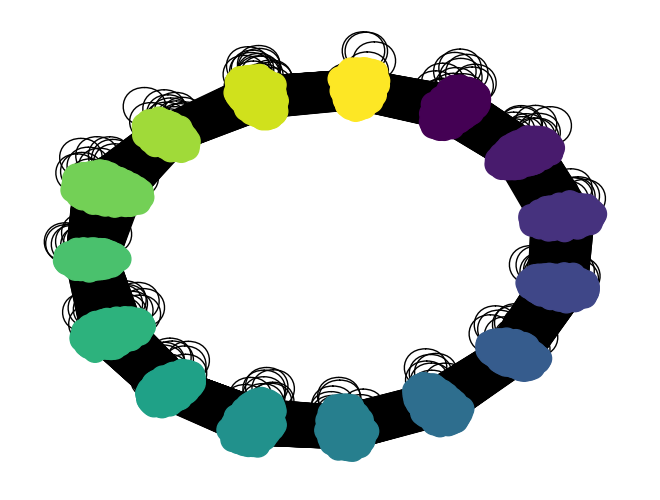

In [2]:
N, K = 2000, 15
r = 0.1
p = 0.4
q = 1 - p - r

edges, dst_edges, community_labels, A = graph_info(p,q,r,K,N)
graph = nx.from_numpy_array(A.numpy())
nx.draw(graph, with_labels=False, node_color=community_labels.numpy(), cmap=plt.cm.viridis)

In [3]:
cfg = ExperimentConfig(
    N=N,
    m=2,
    beta=0.5,
    K=400,
    n_neighbors=10,
    omega_type="random", # Not used here
    function_type="mexican",
    # function_type="coordinates",
    device="cpu",
    export_path=None,
)

In [4]:
epsilon = 1

W, mu_0, mu_1 = gaussian_kernel(edges, dst_edges, epsilon, cfg.N, cfg.m)
c_km = -mu_1 / mu_0 * (cfg.m + 1) / cfg.m

Q_inv_theta = get_Q_inv_theta(W, theta=1)
W_theta_s, W_theta_a = get_W_thetas(W, Q_inv_theta)
P_theta_s, P_theta_a = construct_P_thetas(W_theta_s, W_theta_a)
L_theta_s = 1 / epsilon**2 * P_theta_s
L_theta_a = 1 / epsilon * P_theta_a

In [5]:
# eigenvalues, eigenvectors = torch.linalg.eigh(L_theta_s)
# K = 2
# X_low = eigenvectors[:, :K]

X_low = SpectralEmbedding(n_components=2, affinity='precomputed').fit_transform(W_theta_s.detach().cpu().numpy())
X_low = torch.from_numpy(X_low).float().to(cfg.device)


In [6]:
base_cometric = IdentityCoMetric()
# base_cometric = CentroidsCometric(centroids=X_low,cometric_centroids=base_cometric(X_low))

In [7]:
f_values_low, Lf_values_low, f_grad_values_low = prepare_test_functions(
        # cfg.K, "mexican", X, L_theta_a
        cfg.K, "coordinates", X_low, L_theta_a
    )

[2026-09-16 17:20:59] - INFO - Training vector field models...


Loss: 1.0738e-05: 100%|██████████| 1000/1000 [00:02<00:00, 470.03it/s]


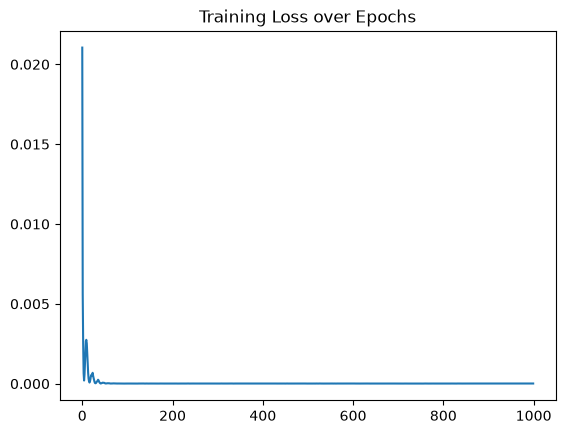

In [8]:
LOGGER.info("Training vector field models...")
v_model, omega_model, loss_list = train_vector_field_models(
    X_low, base_cometric, c_km, f_values_low, Lf_values_low, f_grad_values_low,m=cfg.m,n_epochs=1000
)
v_hat_deep_low = v_model(X_low).detach()
b_hat_deep_low = omega_model(X_low).detach()
plt.plot(loss_list)
plt.title("Training Loss over Epochs")
plt.show()

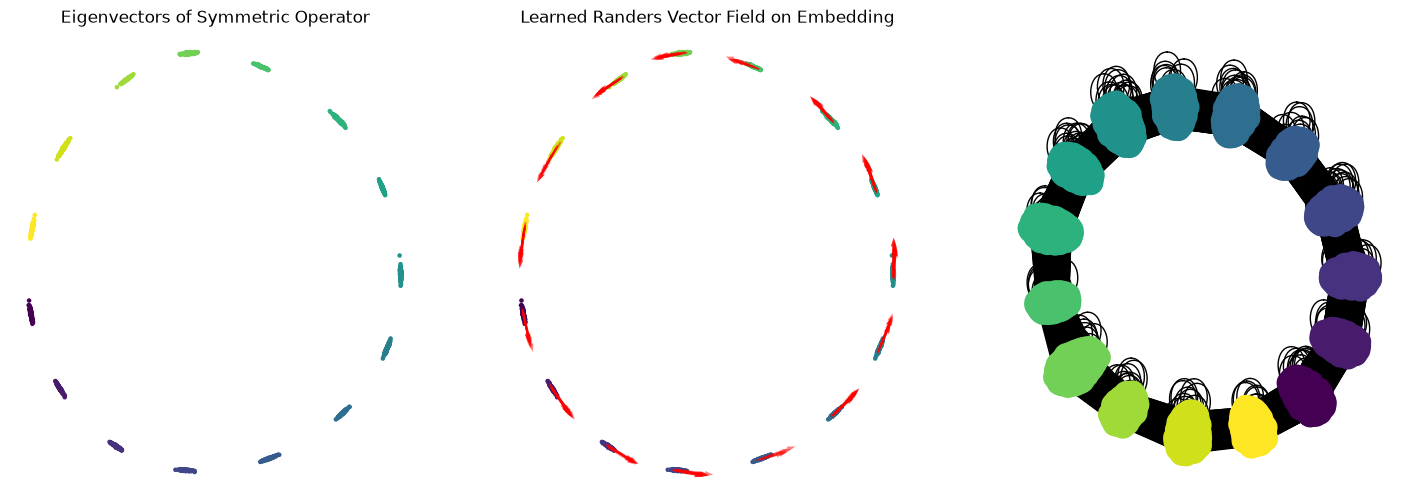

In [9]:
skip=10
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].scatter(X_low[:, 0].detach().cpu(), X_low[:, 1].detach().cpu(), c=community_labels, cmap="viridis", s=5)
axes[0].set_title("Eigenvectors of Symmetric Operator")
axes[1].scatter(X_low[:, 0].detach().cpu(), X_low[:, 1].detach().cpu(), c=community_labels, cmap="viridis", s=5)
axes[1].quiver(
    X_low[::skip, 0].detach().cpu(),
    X_low[::skip, 1].detach().cpu(),
    b_hat_deep_low[::skip, 0].detach().cpu(),
    b_hat_deep_low[::skip, 1].detach().cpu(),
    color="red",
    scale=0.2,
    alpha=0.5,
    angles="xy",
    scale_units="xy"
)
axes[1].set_title("Learned Randers Vector Field on Embedding")
nx.draw(graph, with_labels=False, node_color=community_labels.numpy(), cmap=plt.cm.viridis, ax=axes[2])
for ax in axes:
    ax.axis("off")

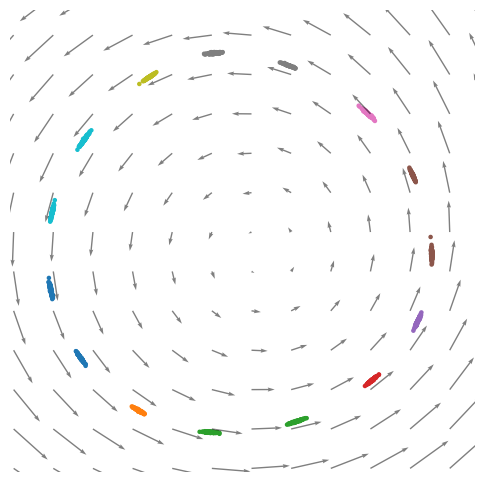

In [10]:
# Meshgrid for vector field visualization
bounds_grid = get_bounds(X_low,margin=0.4)
bounds_plts = get_bounds(X_low,margin=0.1)
x = torch.linspace(bounds_grid[0], bounds_grid[1], 20)
y = torch.linspace(bounds_grid[2], bounds_grid[3], 20)
X, Y = torch.meshgrid(x, y, indexing='ij')
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
omega_grid = omega_model(grid_points).detach()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_low[:, 0].detach().cpu(), X_low[:, 1].detach().cpu(), c=community_labels, cmap="tab10", s=5)
ax.quiver(
    grid_points[:, 0].detach().cpu(),
    grid_points[:, 1].detach().cpu(),
    omega_grid[:, 0].detach().cpu(),
    omega_grid[:, 1].detach().cpu(),
    color="black",
    scale=0.2,
    alpha=0.5,
    angles="xy",
    scale_units="xy"
)
ax.axis("off")
ax.set_xlim(bounds_plts[0], bounds_plts[1])
ax.set_ylim(bounds_plts[2], bounds_plts[3])
plt.savefig("disbm_vector_field.pdf", dpi=300, bbox_inches='tight')